In [1]:
import numpy as np
import matplotlib.pyplot as plt
import umap
from sklearn.manifold import TSNE

import anndata as ad

def _to_numpy(x):
    if hasattr(x, "detach"):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def _build_color_map(unique_labels, cmap=plt.cm.tab20):
    colors = cmap(np.linspace(0, 1, len(unique_labels)))
    return {lab: colors[i] for i, lab in enumerate(unique_labels)}

def plot_embedding_by_label(ax, emb2d, labels, label_to_color, point_size=8, alpha=0.8, title=None, legend=True):
    labels = np.asarray(labels)

    for lab in label_to_color.keys():
        idx = labels == lab
        ax.scatter(
            emb2d[idx, 0], emb2d[idx, 1],
            s=point_size, alpha=alpha,
            c=[label_to_color[lab]],
            edgecolors="none",
            label=str(lab),
        )

    ax.set_xticks([]); ax.set_yticks([])
    if title:
        ax.set_title(title)
    if legend:
        ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", markerscale=2, frameon=False)

def plot_umap_tsne_colored(
    X, labels,
    classes_to_plot=None,
    umap_kwargs=None,
    tsne_kwargs=None,
    point_size=8,
    alpha=0.8,
    cmap=plt.cm.tab20,
):
    X = _to_numpy(X)
    labels = np.asarray(labels)

    # filter to selected classes if requested
    if classes_to_plot is not None:
        mask = np.isin(labels, classes_to_plot)
        X = X[mask]
        labels = labels[mask]

    unique_labels = list(np.unique(labels))
    label_to_color = _build_color_map(unique_labels, cmap=cmap)

    # defaults
    umap_kwargs = umap_kwargs or dict(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=40)
    tsne_kwargs = tsne_kwargs or dict(n_components=2, perplexity=30, learning_rate="auto", init="pca", random_state=40)

    # compute embeddings
    umap_2d = umap.UMAP(**umap_kwargs).fit_transform(X)
    tsne_2d = TSNE(**tsne_kwargs).fit_transform(X)

    # ---- UMAP plot ----
    fig_umap, ax_umap = plt.subplots(figsize=(7, 6))
    plot_embedding_by_label(
        ax_umap,
        umap_2d,
        labels,
        label_to_color,
        point_size,
        alpha,
        title="UMAP Plot of 5 studies with over 1000 samples",
        legend=True,
    )
    plt.show()

    # ---- t-SNE plot ----
    fig_tsne, ax_tsne = plt.subplots(figsize=(7, 6))
    plot_embedding_by_label(
        ax_tsne,
        tsne_2d,
        labels,
        label_to_color,
        point_size,
        alpha,
        title="t-SNE",
        legend=True,
    )
    plt.show()

    return umap_2d, tsne_2d, label_to_color



In [6]:
adata_geography = anndata.read_h5ad("/project/aip-rahulgk/gutmodel/hmc_filtered/finetune_loc_train.h5ad")
adata_geography


NameError: name 'anndata' is not defined

In [ ]:
adata_geography.obs['study_id'].value_counts()

study_id
PRJNA673102    1842
PRJNA510423    1632
PRJNA727279    1197
PRJNA481243    1133
PRJNA436359    1066
               ... 
PRJNA607574      23
PRJNA706727      10
PRJNA531279       5
PRJNA328016       1
PRJEB29433        1
Name: count, Length: 109, dtype: int64

In [ ]:
 # --- labels ---
labels = adata_geography.obs['study_id'].astype(str)

# top-k by frequency
topk = labels.value_counts().head(5).index.tolist()
mask = labels.isin(topk).to_numpy()

# --- X matrix (handle sparse) ---
X = adata_geography.X[mask]
if hasattr(X, "toarray"):  # scipy sparse
    X = X.toarray()
X = np.asarray(X)

labels_sub = labels[mask].to_numpy()

print(f"Data matrix shape: {X.shape}")
print(f"Labels shape: {labels_sub.shape}")


Data matrix shape: (6870, 1514)
Labels shape: (6870,)


/home/kchen13/hmbenv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


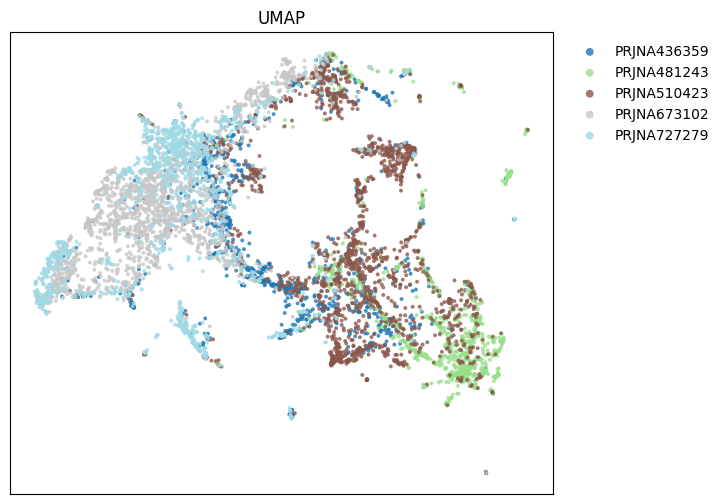

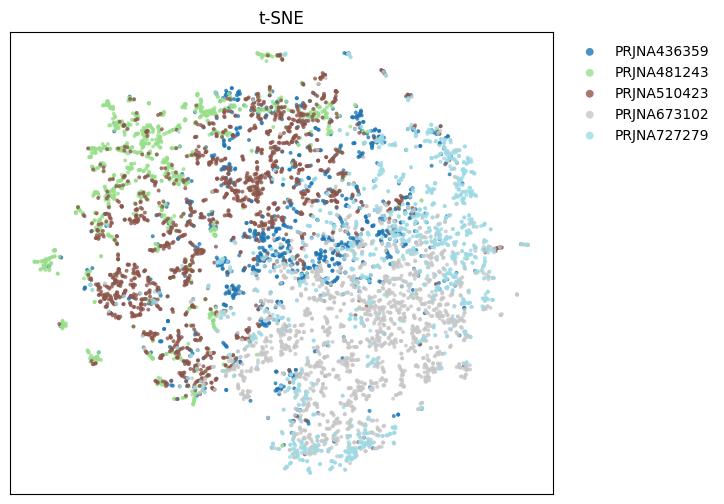

In [ ]:
umap_2d, tsne_2d, label_to_color = plot_umap_tsne_colored(
    X=X,
    labels=labels_sub,      
    classes_to_plot=None,          
    tsne_kwargs=dict(perplexity=10, metric="cosine", random_state=40),
)

In [ ]:
def plot_umap_from_embedding(
    umap_2d,
    labels,
    classes_to_plot=None,
    label_to_color=None,
    cmap=plt.cm.tab20,
    point_size=8,
    alpha=0.8,
    title=None,
    legend=True,
    figsize=(7, 6),
):
    labels = np.asarray(labels)

    # optionally filter classes
    if classes_to_plot is not None:
        mask = np.isin(labels, classes_to_plot)
        umap_2d = umap_2d[mask]
        labels = labels[mask]

    # build colors if not provided
    unique_labels = list(np.unique(labels))
    if label_to_color is None:
        colors = cmap(np.linspace(0, 1, len(unique_labels)))
        label_to_color = {lab: colors[i] for i, lab in enumerate(unique_labels)}

    fig, ax = plt.subplots(figsize=figsize)

    for lab in unique_labels:
        idx = labels == lab
        ax.scatter(
            umap_2d[idx, 0],
            umap_2d[idx, 1],
            s=point_size,
            alpha=alpha,
            c=[label_to_color[lab]],
            edgecolors="none",
            label=str(lab),
        )

    ax.set_xticks([])
    ax.set_yticks([])
    if title:
        ax.set_title(title)
    if legend:
        ax.legend(
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            frameon=False,
            markerscale=2,
        )

    plt.show()


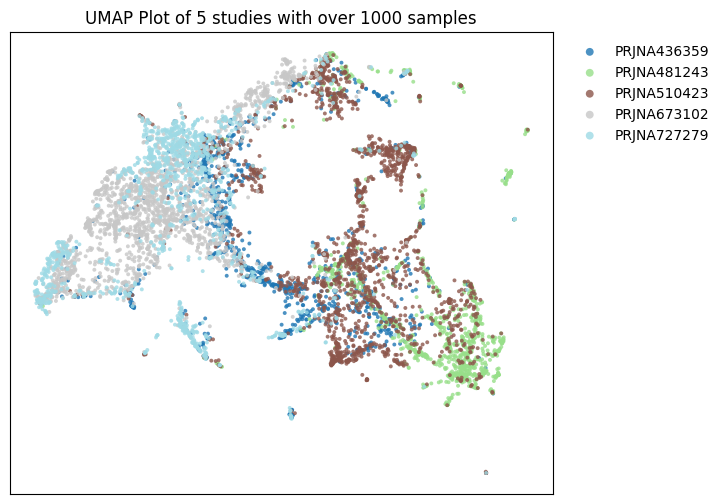

In [ ]:
plot_umap_from_embedding(
    umap_2d,
    labels_sub,
    label_to_color=label_to_color,
    title="UMAP Plot of 5 studies with over 1000 samples",
)


Get counts

In [2]:
train = ad.read_h5ad("/project/aip-rahulgk/gutmodel/remove_redundant_oct24/finetune_train.h5ad")
test = ad.read_h5ad("/project/aip-rahulgk/gutmodel/remove_redundant_oct24/finetune_test.h5ad")

/home/kchen13/hmbenv/lib/python3.11/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/kchen13/hmbenv/lib/python3.11/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [3]:
train

AnnData object with n_obs × n_vars = 52266 × 4296
    obs: 'study_id', 'continuous_label', 'categorical_label', 'downstream_task'
    var: 'taxa'
    varm: 'taxonomy'

In [4]:
test

AnnData object with n_obs × n_vars = 13758 × 4296
    obs: 'study_id', 'continuous_label', 'categorical_label', 'downstream_task'
    var: 'taxa'
    varm: 'taxonomy'

In [5]:
test.obs['downstream_task'].value_counts()

downstream_task
location      9644
sex           1514
age           1120
bmi            751
mice_diet      318
supplement     241
human_diet     170
Name: count, dtype: int64

In [10]:
test[test.obs["downstream_task"] == "location"].obs['study_id'].value_counts().sort_index()

study_id
PRJDB10527       91
PRJDB11845      103
PRJEB28700       56
PRJEB36385      198
PRJEB40751      303
PRJNA279828     160
PRJNA324452     168
PRJNA352060     850
PRJNA395034     142
PRJNA396901     113
PRJNA398089     176
PRJNA416445      80
PRJNA421371      80
PRJNA437504     407
PRJNA489137     120
PRJNA517572     558
PRJNA544370     340
PRJNA545312    3690
PRJNA556249     248
PRJNA558158      97
PRJNA559898      63
PRJNA578412      75
PRJNA604280     269
PRJNA604466      53
PRJNA645223     320
PRJNA674880     214
PRJNA718687      69
PRJNA729439      50
PRJNA761978     466
PRJNA762104      85
Name: count, dtype: int64

In [11]:
train[train.obs["downstream_task"] == "location"].obs['study_id'].value_counts().sort_index()

study_id
PRJDB8511      114
PRJDB10612     117
PRJEB3360      166
PRJEB6358      531
PRJEB6518      534
              ... 
PRJNA724686    100
PRJNA750230     88
PRJNA750272     90
PRJNA753264     52
PRJNA762994    186
Name: count, Length: 112, dtype: int64

In [8]:
def count_samples_by_study(adata, study_ids, obs_key="study_id"):
    """
    Count samples whose obs[obs_key] is in study_ids.

    Args:
        adata (anndata.AnnData)
        study_ids (list[str])
        obs_key (str): column name in adata.obs

    Returns:
        int: number of matching samples
    """
    return adata.obs[obs_key].isin(study_ids).sum()


In [9]:
age_train = ["PRJNA729511", "PRJNA485316"]
count_samples_by_study(train, age_train)

np.int64(7670)